# Music Emotion Prediction Pipeline
**audio → mel-spectrogram → CNN → valence/arousal → emotion label**

Dataset: [DEAM on Kaggle](https://www.kaggle.com/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music)

```
High Arousal
     │
tense│ happy
─────┼───────  High Valence
  sad│ calm
     │
Low Arousal
```

## Cell 1 — Install Dependencies

In [ ]:
!pip install -q kaggle librosa numpy pandas tensorflow scikit-learn joblib

## Cell 2 — Kaggle API Setup

In [ ]:
from google.colab import userdata
import os



os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

## Cell 3 — Download & Extract DEAM Dataset

In [ ]:
!kaggle datasets download -d imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music -p /content/deam
!unzip -q /content/deam/deam-mediaeval-dataset-emotional-analysis-in-music.zip -d /content/deam
print('\nExtracted files:')
!ls /content/deam

Dataset URL: https://www.kaggle.com/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music
License(s): CC-BY-NC-SA-4.0
100% 1.83G/1.83G [00:21<00:00, 91.2MB/s]


Extracted files:
DEAM_Annotations  deam-mediaeval-dataset-emotional-analysis-in-music.zip
DEAM_audio	  features


## Cell 4 — Verify Paths

In [ ]:
import os

DATASET_ROOT = '/content/deam'

# Walk the extracted structure to find audio and annotations automatically
AUDIO_DIR, ANNO_CSV = None, None

for root, dirs, files_found in os.walk(DATASET_ROOT):
    for d in dirs:
        if d == 'MEMD_audio':
            AUDIO_DIR = os.path.join(root, d)
    for f in files_found:
        if f == 'static_annotations_averaged_songs_1_2000.csv':
            ANNO_CSV = os.path.join(root, f)

MODEL_DIR = '/content/emotion_model'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'Audio dir  : {AUDIO_DIR}')
print(f'Anno CSV   : {ANNO_CSV}')
print(f'Model dir  : {MODEL_DIR}')

assert AUDIO_DIR and os.path.exists(AUDIO_DIR), 'Audio directory not found!'
assert ANNO_CSV  and os.path.exists(ANNO_CSV),  'Annotations CSV not found!'
print('\nAll paths verified ✓')

# Quick sanity check — count mp3s
mp3s = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.mp3')]
print(f'MP3 files found: {len(mp3s)}')

Audio dir  : /content/deam/DEAM_audio/MEMD_audio
Anno CSV   : /content/deam/DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv
Model dir  : /content/emotion_model

All paths verified ✓
MP3 files found: 1802


## Cell 5 — Imports & Config

In [ ]:
import math
import warnings
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

# ── Audio config ──────────────────────────────────────────────────────
SR           = 44100
SEGMENT_SECS = 5
N_MELS       = 128
N_FFT        = 2048
HOP_LENGTH   = 512
SEG_FRAMES   = int(math.ceil(SEGMENT_SECS * SR / HOP_LENGTH))  # 431

# ── Emotion config ────────────────────────────────────────────────────
MIDPOINT = 5.0   # centre of 1-9 scale
MARGIN   = 0.5   # dead-zone — songs within ±0.5 of midpoint become 'ambiguous'

print(f'TF {tf.__version__}  |  GPU: {tf.config.list_physical_devices("GPU")}')
print(f'Mel shape per segment: ({N_MELS}, {SEG_FRAMES})')

TF 2.19.0  |  GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mel shape per segment: (128, 431)


## Cell 6 — Load & Label Annotations

Total annotated songs : 1744

Emotion distribution:
emotion
ambiguous    729
sad          477
happy        385
tense         82
calm          71


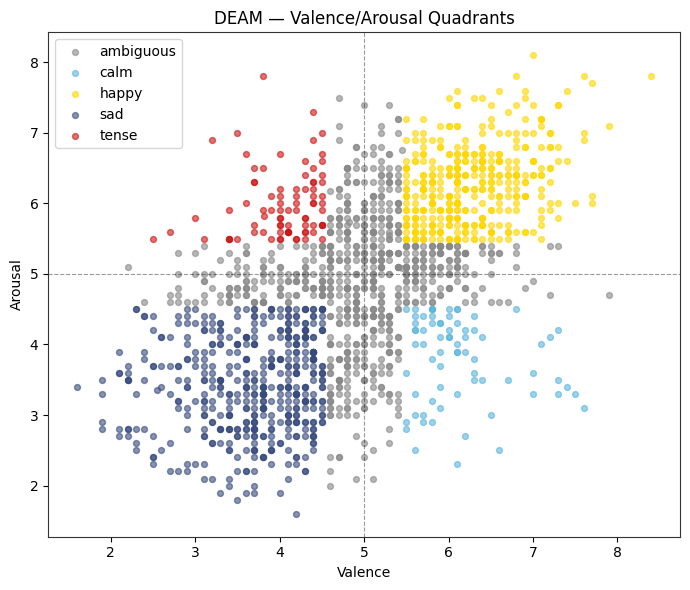

In [ ]:
def load_annotations(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    rename = {}
    for c in df.columns:
        if 'valence' in c.lower() and 'mean' in c.lower(): rename[c] = 'valence_mean'
        if 'arousal' in c.lower() and 'mean' in c.lower(): rename[c] = 'arousal_mean'
    df = df.rename(columns=rename)
    df = df[['song_id', 'valence_mean', 'arousal_mean']].dropna()
    df['song_id'] = df['song_id'].astype(int)
    return df

def assign_emotion(valence, arousal, midpoint=MIDPOINT, margin=MARGIN):
    """Map (valence, arousal) → emotion quadrant with a dead-zone."""
    high_v = valence >= midpoint + margin
    low_v  = valence <= midpoint - margin
    high_a = arousal >= midpoint + margin
    low_a  = arousal <= midpoint - margin
    if   high_v and high_a: return 'happy'
    elif high_v and low_a:  return 'calm'
    elif low_v  and high_a: return 'tense'
    elif low_v  and low_a:  return 'sad'
    else:                   return 'ambiguous'

anno_df = load_annotations(ANNO_CSV)
anno_df['emotion'] = anno_df.apply(
    lambda r: assign_emotion(r['valence_mean'], r['arousal_mean']), axis=1
)

print(f'Total annotated songs : {len(anno_df)}')
print('\nEmotion distribution:')
print(anno_df['emotion'].value_counts().to_string())

# Valence-Arousal scatter
emotion_colors = {
    'happy':'#FFD700','calm':'#5AB4DC',
    'sad':'#374B7D','tense':'#CD1414','ambiguous':'#888'
}
fig, ax = plt.subplots(figsize=(7,6))
for emo, grp in anno_df.groupby('emotion'):
    ax.scatter(grp['valence_mean'], grp['arousal_mean'],
               c=emotion_colors[emo], label=emo, alpha=0.6, s=18)
ax.axvline(MIDPOINT, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axhline(MIDPOINT, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.tick_params()
for sp in ax.spines.values(): sp.set_color('#333')
ax.set_xlabel('Valence'); ax.set_ylabel('Arousal')
ax.set_title('DEAM — Valence/Arousal Quadrants')
ax.legend()
plt.tight_layout(); plt.show()

## Cell 7 — Extract Mel-Spectrograms

In [ ]:
def song_to_mel_segments(audio_path):
    y, sr = librosa.load(audio_path, sr=SR, mono=True)
    seg_len  = SEGMENT_SECS * sr
    segments = [y[i:i+seg_len] for i in range(0, len(y), seg_len)
                if len(y[i:i+seg_len]) == seg_len]
    mel_list = []
    for seg in segments:
        mel    = librosa.feature.melspectrogram(y=seg, sr=sr,
                    n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        # Pad or trim to fixed width
        if mel_db.shape[1] < SEG_FRAMES:
            mel_db = np.pad(mel_db, ((0,0),(0, SEG_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :SEG_FRAMES]
        mel_list.append(mel_db)
    return mel_list

usable  = anno_df[anno_df['emotion'] != 'ambiguous'].copy()
print(f'Songs after dropping ambiguous: {len(usable)}')

X_by_song = {}
y_by_song = {}
skipped   = 0

for i, (_, row) in enumerate(usable.iterrows()):
    sid   = row['song_id']
    fpath = os.path.join(AUDIO_DIR, f'{sid}.mp3')
    if not os.path.exists(fpath):
        skipped += 1; continue
    try:
        segs = song_to_mel_segments(fpath)
        if len(segs) == 0:
            skipped += 1; continue
        X_by_song[sid] = segs
        y_by_song[sid] = [[row['valence_mean'], row['arousal_mean']]] * len(segs)
    except Exception as e:
        skipped += 1
    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(usable)} processed...')

print(f'\nSongs loaded: {len(X_by_song)}   |   skipped: {skipped}')

Songs after dropping ambiguous: 1015
  100/1015 processed...
  200/1015 processed...
  300/1015 processed...
  400/1015 processed...
  500/1015 processed...
  600/1015 processed...
  700/1015 processed...
  800/1015 processed...
  900/1015 processed...
  1000/1015 processed...

Songs loaded: 1015   |   skipped: 0


## Cell 8 — Song-Level Train / Val / Test Split

In [ ]:
song_ids = list(X_by_song.keys())
train_ids, tmp_ids = train_test_split(song_ids, test_size=0.30, random_state=42)
val_ids,  test_ids = train_test_split(tmp_ids,  test_size=0.50, random_state=42)

def flatten(ids):
    X, y = [], []
    for sid in ids:
        X.extend(X_by_song[sid])
        y.extend(y_by_song[sid])
    X = np.expand_dims(np.array(X, dtype=np.float32), axis=-1)
    y = np.array(y, dtype=np.float32)
    return X, y

X_train, y_train = flatten(train_ids)
X_val,   y_val   = flatten(val_ids)
X_test,  y_test  = flatten(test_ids)

print(f'Train : {X_train.shape}  ({len(train_ids)} songs)')
print(f'Val   : {X_val.shape}  ({len(val_ids)} songs)')
print(f'Test  : {X_test.shape}  ({len(test_ids)} songs)')

Train : (6387, 128, 431, 1)  (710 songs)
Val   : (1366, 128, 431, 1)  (152 songs)
Test  : (1375, 128, 431, 1)  (153 songs)


## Cell 9 — Normalise Labels

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(y_train.reshape(-1, 2))

y_train_n = scaler.transform(y_train.reshape(-1, 2)).reshape(y_train.shape)
y_val_n   = scaler.transform(y_val.reshape(-1, 2)).reshape(y_val.shape)
y_test_n  = scaler.transform(y_test.reshape(-1, 2)).reshape(y_test.shape)

joblib.dump(scaler, os.path.join(MODEL_DIR, 'label_scaler.pkl'))
print(f'Scaler saved.')
print(f'  Valence range : [{scaler.data_min_[0]:.2f}, {scaler.data_max_[0]:.2f}]')
print(f'  Arousal range : [{scaler.data_min_[1]:.2f}, {scaler.data_max_[1]:.2f}]')

Scaler saved.
  Valence range : [1.60, 7.90]
  Arousal range : [1.90, 8.10]


## Cell 10 — Build CNN Model

In [ ]:
def build_cnn(input_shape=(N_MELS, SEG_FRAMES, 1)):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32,  (3,3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64,  (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(2, activation='sigmoid')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

cnn = build_cnn()
cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 431, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 431, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 431, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 215, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 215, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 215, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 107, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 107, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 107, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 53, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 53, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,706 (1.86 MB)

 Trainable params: 487,746 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

## Cell 11 — Train

In [ ]:
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'best_cnn_model.keras')

cb = [
    callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint(BEST_MODEL_PATH, save_best_only=True, verbose=0),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

history = cnn.fit(
    X_train, y_train_n,
    validation_data=(X_val, y_val_n),
    epochs=60,
    batch_size=32,
    callbacks=cb,
)

Epoch 1/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 128ms/step - loss: 0.0300 - mae: 0.1373 - val_loss: 0.0321 - val_mae: 0.1456 - learning_rate: 0.0010
Epoch 2/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - loss: 0.0257 - mae: 0.1263 - val_loss: 0.0806 - val_mae: 0.2312 - learning_rate: 0.0010
Epoch 3/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.0237 - mae: 0.1204 - val_loss: 0.0291 - val_mae: 0.1367 - learning_rate: 0.0010
Epoch 4/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - loss: 0.0228 - mae: 0.1176 - val_loss: 0.0418 - val_mae: 0.1696 - learning_rate: 0.0010
Epoch 5/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.0216 - mae: 0.1141 - val_loss: 0.0229 - val_mae: 0.1219 - learning_rate: 0.0010
Epoch 6/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.0209 - mae: 0.1116 - val_loss: 0.0417 - val_mae: 0.1567 - learning_rate: 0.0010
Epoch 7/60
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - loss: 0.0199 - mae: 0.1089 - val_loss: 0.0261 - val_mae: 0.1289 - learning_rate

## Cell 12 — Training Curves

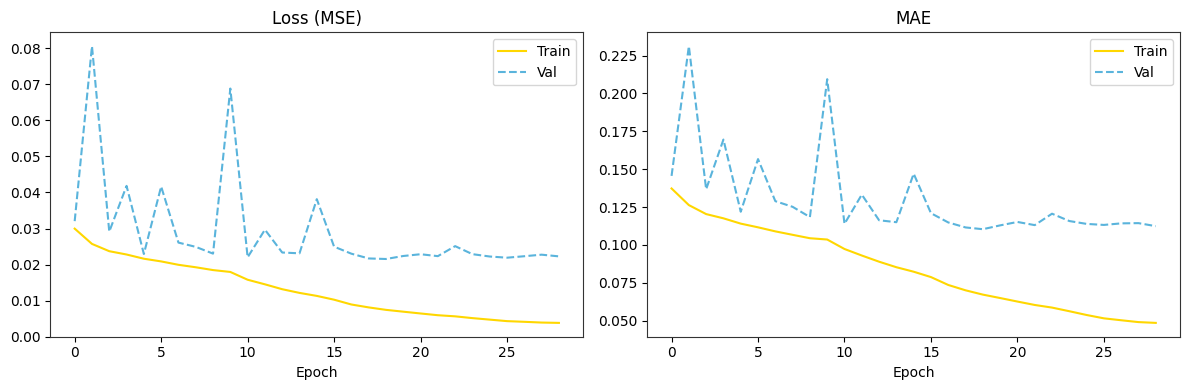

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(
    axes,
    [('loss','val_loss'), ('mae','val_mae')],
    ['Loss (MSE)', 'MAE']
):

    ax.plot(history.history[metric[0]], color='#FFD700', label='Train')
    ax.plot(history.history[metric[1]], color='#5AB4DC', label='Val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.tick_params()
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.legend()
plt.tight_layout(); plt.show()

## Cell 13 — Evaluate on Test Set

── Test Results (original 1–9 scale) ─────────────────
  Valence  MAE=0.744   RMSE=0.968
  Arousal  MAE=0.683   RMSE=0.937


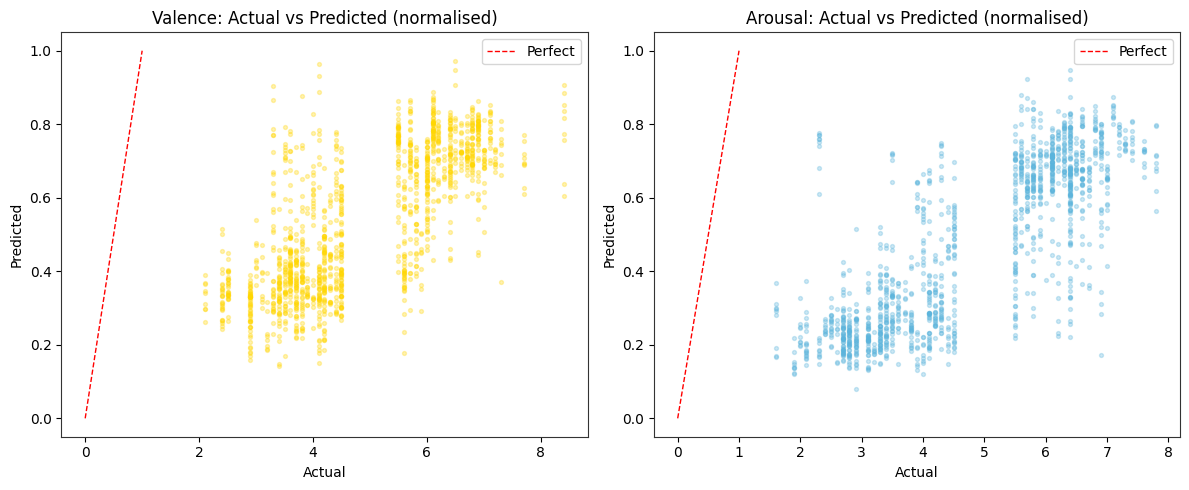

In [ ]:
y_pred_n = cnn.predict(X_test, verbose=0)
y_pred   = scaler.inverse_transform(y_pred_n)
y_true   = scaler.inverse_transform(y_test_n)

mae_v  = np.mean(np.abs(y_pred[:,0] - y_true[:,0]))
mae_a  = np.mean(np.abs(y_pred[:,1] - y_true[:,1]))
rmse_v = np.sqrt(np.mean((y_pred[:,0] - y_true[:,0])**2))
rmse_a = np.sqrt(np.mean((y_pred[:,1] - y_true[:,1])**2))

print('── Test Results (original 1–9 scale) ─────────────────')
print(f'  Valence  MAE={mae_v:.3f}   RMSE={rmse_v:.3f}')
print(f'  Arousal  MAE={mae_a:.3f}   RMSE={rmse_a:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dim, color, label in zip(
    axes, [0,1], ['#FFD700','#5AB4DC'], ['Valence','Arousal']
):
    ax.scatter(y_true[:,dim], y_pred_n[:,dim], alpha=0.3, s=8, color=color)
    ax.plot([0,1],[0,1],'r--',lw=1,label='Perfect')
    ax.set_title(f'{label}: Actual vs Predicted (normalised)')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.tick_params()
    for sp in ax.spines.values(): sp.set_color('#333')
    ax.legend()
plt.tight_layout(); plt.show()

## Cell 14 — Song-Level Emotion Accuracy

In [ ]:
correct = 0
results = []

for sid in test_ids:
    if sid not in X_by_song: continue
    X_song    = np.expand_dims(np.array(X_by_song[sid], dtype=np.float32), -1)
    preds_n   = cnn.predict(X_song, verbose=0)
    mean_orig = scaler.inverse_transform([preds_n.mean(axis=0)])[0]
    v, a      = float(mean_orig[0]), float(mean_orig[1])
    pred_emo  = assign_emotion(v, a)
    true_emo  = anno_df[anno_df['song_id'] == sid]['emotion'].values[0]
    match     = pred_emo == true_emo
    correct  += int(match)
    results.append({
        'song_id':  sid, 'true_emo': true_emo, 'pred_emo': pred_emo,
        'valence':  round(v,2), 'arousal': round(a,2), 'correct': match
    })

results_df = pd.DataFrame(results)
print(f'Song-level emotion accuracy: {correct/len(results_df):.1%}  ({correct}/{len(results_df)})')
print('\nPer-emotion breakdown:')
print(results_df.groupby('true_emo')['correct']
      .agg(['sum','count'])
      .rename(columns={'sum':'correct','count':'total'})
      .assign(accuracy=lambda d: (d['correct']/d['total']).round(3)))

Song-level emotion accuracy: 71.9%  (110/153)

Per-emotion breakdown:
          correct  total  accuracy
true_emo                          
calm            0      9     0.000
happy          49     61     0.803
sad            60     68     0.882
tense           1     15     0.067


## Cell 15 — `predict_emotion()` Function

In [ ]:
def predict_emotion(audio_path, model_path=None, scaler_path=None):
    """
    Predict dominant emotion for any audio file.

    Returns
    -------
    {
        'emotion':       'happy' | 'calm' | 'sad' | 'tense' | 'ambiguous',
        'valence':       float,    # 1-9 scale
        'arousal':       float,    # 1-9 scale
        'confidence':    float,    # 0-1
        'probabilities': dict
    }
    """
    _model  = models.load_model(model_path) if model_path else cnn
    _scaler = joblib.load(scaler_path)      if scaler_path else scaler

    y_audio, sr = librosa.load(audio_path, sr=SR, mono=True)
    seg_len  = SEGMENT_SECS * sr
    segments = [y_audio[i:i+seg_len] for i in range(0, len(y_audio), seg_len)
                if len(y_audio[i:i+seg_len]) == seg_len]
    if not segments:
        raise ValueError(f'Audio too short (need >= {SEGMENT_SECS}s): {audio_path}')

    mel_list = []
    for seg in segments:
        mel    = librosa.feature.melspectrogram(y=seg, sr=sr,
                    n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        if mel_db.shape[1] < SEG_FRAMES:
            mel_db = np.pad(mel_db, ((0,0),(0, SEG_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :SEG_FRAMES]
        mel_list.append(mel_db)

    X = np.expand_dims(np.array(mel_list, dtype=np.float32), -1)

    preds_n   = _model.predict(X, verbose=0)
    mean_orig = _scaler.inverse_transform([preds_n.mean(axis=0)])[0]
    valence   = float(mean_orig[0])
    arousal   = float(mean_orig[1])
    emotion   = assign_emotion(valence, arousal)

    centroids = {'happy':(7.,7.),'calm':(7.,3.),'sad':(3.,3.),'tense':(3.,7.)}
    inv   = {e: 1/(math.sqrt((valence-cv)**2+(arousal-ca)**2)+1e-6)
             for e,(cv,ca) in centroids.items()}
    total = sum(inv.values())
    probs = {e: round(v/total,3) for e,v in inv.items()}

    dist_mid   = math.sqrt((valence-MIDPOINT)**2+(arousal-MIDPOINT)**2)
    confidence = round(min(dist_mid/(MIDPOINT-1),1.0),3)

    return {
        'emotion':       emotion,
        'valence':       round(valence,2),
        'arousal':       round(arousal,2),
        'confidence':    confidence,
        'probabilities': probs,
    }

## Cell 16 — Test on a Known DEAM Song

Song ID   : 1298
True      : happy  (V=6.9, A=5.6)
Predicted : ambiguous  (V=5.54, A=5.46)
Confidence: 0.177
Probs     : {'happy': 0.327, 'calm': 0.242, 'sad': 0.196, 'tense': 0.234}


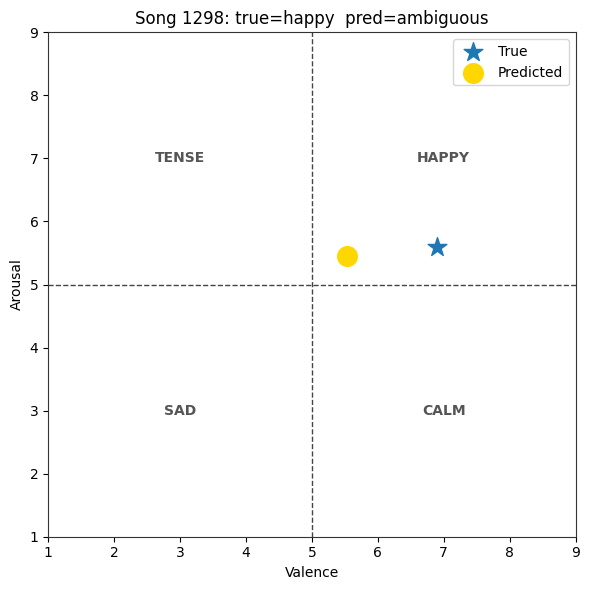

In [ ]:
test_song_id = test_ids[0]
test_audio   = os.path.join(AUDIO_DIR, f'{test_song_id}.mp3')
result       = predict_emotion(test_audio)

true_emo = anno_df[anno_df['song_id']==test_song_id]['emotion'].values[0]
true_va  = anno_df[anno_df['song_id']==test_song_id][['valence_mean','arousal_mean']].values[0]

print(f'Song ID   : {test_song_id}')
print(f'True      : {true_emo}  (V={true_va[0]:.1f}, A={true_va[1]:.1f})')
print(f'Predicted : {result["emotion"]}  (V={result["valence"]}, A={result["arousal"]})')
print(f'Confidence: {result["confidence"]}')
print(f'Probs     : {result["probabilities"]}')

fig, ax = plt.subplots(figsize=(6,6))
ax.axvline(MIDPOINT,color='#444',lw=1,linestyle='--')
ax.axhline(MIDPOINT,color='#444',lw=1,linestyle='--')
for lbl,(cx,cy) in [('HAPPY',(7,7)),('CALM',(7,3)),('SAD',(3,3)),('TENSE',(3,7))]:
    ax.text(cx,cy,lbl,ha='center',va='center',color='#555',fontsize=10,fontweight='bold')
ax.scatter(true_va[0],true_va[1],s=200,marker='*',zorder=5,label='True')
ax.scatter(result['valence'],result['arousal'],s=200,marker='o',color='#FFD700',zorder=5,label='Predicted')
ax.set_xlim(1,9); ax.set_ylim(1,9)
ax.set_xlabel('Valence'); ax.set_ylabel('Arousal')
ax.set_title(f'Song {test_song_id}: true={true_emo}  pred={result["emotion"]}')
ax.tick_params()
for sp in ax.spines.values(): sp.set_color('#333')
ax.legend()
plt.tight_layout(); plt.show()

## Cell 17 — Predict on Your Own MP3/WAV

Upload any MP3 or WAV file:


Saving SuiteNo3.mp3 to SuiteNo3.mp3

────────────────────────────────────────
  Emotion    : SAD
  Valence    : 3.85 / 9
  Arousal    : 3.32 / 9
  Confidence : 0.509
  Probs      : {'happy': 0.109, 'calm': 0.168, 'sad': 0.583, 'tense': 0.14}
────────────────────────────────────────


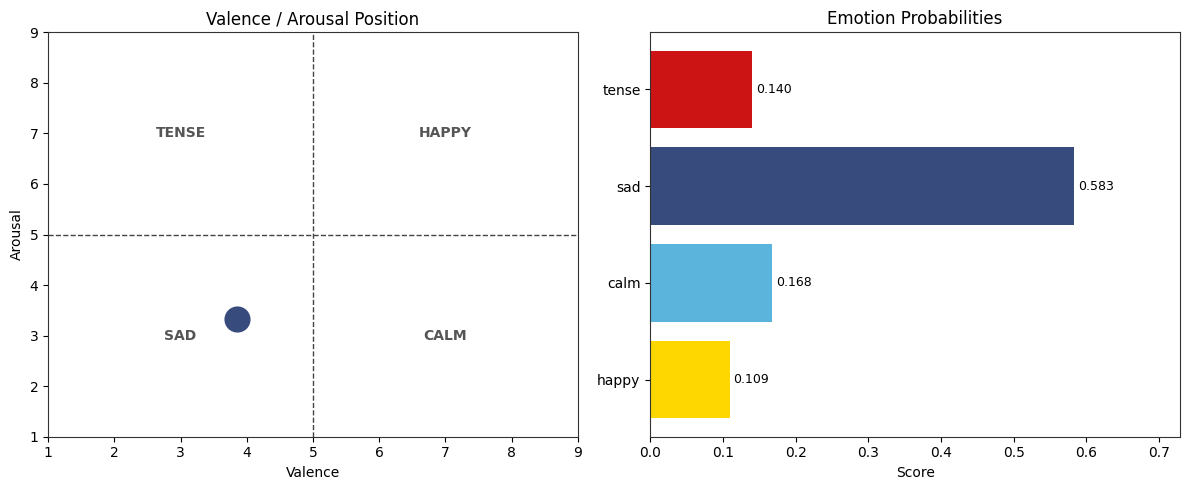

In [ ]:
from google.colab import files as colab_files

print('Upload any MP3 or WAV file:')
uploaded      = colab_files.upload()
uploaded_path = list(uploaded.keys())[0]

result = predict_emotion(uploaded_path)

print(f"\n{'─'*40}")
print(f"  Emotion    : {result['emotion'].upper()}")
print(f"  Valence    : {result['valence']} / 9")
print(f"  Arousal    : {result['arousal']} / 9")
print(f"  Confidence : {result['confidence']}")
print(f"  Probs      : {result['probabilities']}")
print(f"{'─'*40}")

emotion_colors = {'happy':'#FFD700','calm':'#5AB4DC',
                  'sad':'#374B7D','tense':'#CD1414','ambiguous':'#888'}

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: V/A plane
ax = axes[0];
ax.axvline(MIDPOINT,color='#444',lw=1,linestyle='--')
ax.axhline(MIDPOINT,color='#444',lw=1,linestyle='--')
for lbl,(cx,cy) in [('HAPPY',(7,7)),('CALM',(7,3)),('SAD',(3,3)),('TENSE',(3,7))]:
    ax.text(cx,cy,lbl,ha='center',va='center',color='#555',fontsize=10,fontweight='bold')
c = emotion_colors.get(result['emotion'],'#888')
ax.scatter(result['valence'],result['arousal'],s=300,color=c,zorder=5,linewidths=1.5)
ax.set_xlim(1,9); ax.set_ylim(1,9)
ax.set_xlabel('Valence'); ax.set_ylabel('Arousal')
ax.set_title('Valence / Arousal Position')
ax.tick_params()
for sp in ax.spines.values(): sp.set_color('#333')

# Right: probability bars
ax2 = axes[1];
emos  = list(result['probabilities'].keys())
probs = list(result['probabilities'].values())
cols  = [emotion_colors[e] for e in emos]
bars  = ax2.barh(emos, probs, color=cols)
ax2.set_xlim(0, max(probs)*1.25)
ax2.set_title('Emotion Probabilities')
ax2.set_xlabel('Score')
ax2.tick_params()
for sp in ax2.spines.values(): sp.set_color('#333')
for bar,p in zip(bars,probs):
    ax2.text(bar.get_width()+0.005,bar.get_y()+bar.get_height()/2,
             f'{p:.3f}',va='center',fontsize=9)
plt.tight_layout(); plt.show()

## Cell 18 — Save Model to Google Drive

In [ ]:
import json

cnn.save(BEST_MODEL_PATH)
joblib.dump(scaler, os.path.join(MODEL_DIR, 'label_scaler.pkl'))

config = {
    'sample_rate':  SR,
    'segment_secs': SEGMENT_SECS,
    'n_mels':       N_MELS,
    'n_fft':        N_FFT,
    'hop_length':   HOP_LENGTH,
    'seg_frames':   SEG_FRAMES,
    'midpoint':     MIDPOINT,
    'margin':       MARGIN,
    'model_path':   BEST_MODEL_PATH,
    'scaler_path':  os.path.join(MODEL_DIR, 'label_scaler.pkl'),
}
with open(os.path.join(MODEL_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved to {MODEL_DIR}/')
print('  best_cnn_model.keras')
print('  label_scaler.pkl')
print('  config.json')

# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# shutil.copytree(MODEL_DIR, '/content/drive/MyDrive/DEAM/emotion_model', dirs_exist_ok=True)
# print('Copied to Drive ✓')

Saved to /content/emotion_model/
  best_cnn_model.keras
  label_scaler.pkl
  config.json


Final Code - helper functions that call the model

In [ ]:
import math
import json
import os
import numpy as np
import librosa
import joblib
from tensorflow.keras import models

def load_emotion_artifacts(model_path, scaler_path):
    model = models.load_model(model_path)
    scaler = joblib.load(scaler_path)
    return model, scaler


def predict_emotion_chunks(
    audio_path,
    model_path,
    scaler_path,
    chunk_secs=20
):
    """
    Predict one emotion label per chunk of audio.

    Returns:
        [
            {
                "start": 0.0,
                "end": 20.0,
                "emotion": "calm",
                "valence": 6.21,
                "arousal": 3.77
            },
            ...
        ]
    """
    model, scaler = load_emotion_artifacts(model_path, scaler_path)

    y_audio, sr = librosa.load(audio_path, sr=SR, mono=True)
    chunk_len = int(chunk_secs * sr)

    results = []

    for start_idx in range(0, len(y_audio), chunk_len):
        chunk = y_audio[start_idx:start_idx + chunk_len]

        # skip very tiny tail chunk
        if len(chunk) < chunk_len // 2:
            continue

        seg_len = int(SEGMENT_SECS * sr)
        segments = [
            chunk[i:i + seg_len]
            for i in range(0, len(chunk), seg_len)
            if len(chunk[i:i + seg_len]) == seg_len
        ]

        if not segments:
            continue

        mel_list = []
        for seg in segments:
            mel = librosa.feature.melspectrogram(
                y=seg,
                sr=sr,
                n_mels=N_MELS,
                n_fft=N_FFT,
                hop_length=HOP_LENGTH
            )
            mel_db = librosa.power_to_db(mel, ref=np.max)

            if mel_db.shape[1] < SEG_FRAMES:
                mel_db = np.pad(
                    mel_db,
                    ((0, 0), (0, SEG_FRAMES - mel_db.shape[1]))
                )
            else:
                mel_db = mel_db[:, :SEG_FRAMES]

            mel_list.append(mel_db)

        X = np.expand_dims(np.array(mel_list, dtype=np.float32), -1)
        preds_n = model.predict(X, verbose=0)

        mean_orig = scaler.inverse_transform([preds_n.mean(axis=0)])[0]
        valence = float(mean_orig[0])
        arousal = float(mean_orig[1])
        emotion = assign_emotion(valence, arousal)

        results.append({
            "start": round(start_idx / sr, 3),
            "end": round(min((start_idx + chunk_len) / sr, len(y_audio) / sr), 3),
            "emotion": emotion,
            "valence": round(valence, 3),
            "arousal": round(arousal, 3),
        })

    return results


def save_emotion_chunks(
    audio_path,
    model_path,
    scaler_path,
    output_json="emotion_chunks.json",
    chunk_secs=20
):
    chunks = predict_emotion_chunks(
        audio_path=audio_path,
        model_path=model_path,
        scaler_path=scaler_path,
        chunk_secs=chunk_secs
    )

    with open(output_json, "w") as f:
        json.dump(chunks, f, indent=2)

    return chunks